In [1]:
import pandas as pd
import numpy as np
import gc
import os, pickle
import matplotlib.pyplot as plt
import datetime
from warnings import simplefilter
from functools import partial

from tqdm.auto import tqdm
import datetime as dt
from pathlib import Path
from functools import reduce

import torch

tqdm.pandas()

simplefilter(action="ignore", category=pd.errors.PerformanceWarning)
simplefilter(action="ignore", category=pd.errors.DtypeWarning)
pd.set_option('display.max_columns', None)

from pandarallel import pandarallel
pandarallel.initialize()

INFO: Pandarallel will run on 64 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


In [2]:
core_mimiciv_path = "/home/DAHS1/gangmin/my_research/data/mimic-iv/"
store_dir = '/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/full_data/subject_data/mimic_3_1/'

key_id_icu = pd.read_feather(store_dir + 'key_id_static.ftr')

df_ditems = pd.read_parquet(core_mimiciv_path + "/icu/parquet/d_items.parquet")
df_dlabitems = pd.read_parquet(core_mimiciv_path + "/hosp/parquet/d_labitems.parquet")

# Outtime 결측값 제외
key_id_icu = key_id_icu.dropna(subset=['outtime']).reset_index(drop=True)

In [3]:
# sequential df 불러오기
sequential_df_fluid = pd.read_feather(store_dir + "subject_sequential_df_fluid.ftr")
sequential_df_bp = pd.read_feather(store_dir + "subject_sequential_df_bp.ftr")

# w/ BNP
lab_imputed_chart = pd.read_feather(store_dir + "subject_lab_imputed_chart.ftr")

sequential_df_output = pd.read_feather(store_dir + "subject_sequential_df_output.ftr")

---

# 2. DuETT Preprocessing

In [4]:
static_info = pd.read_csv('/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/mimic/physionet.org/files/mimiciv/3.1/hosp/static_info.csv')

In [5]:
static_info.head()

,stay_id,hadm_id,subject_id,intime,outtime,admittime,dischtime,edregtime,edouttime,first_careunit,last_careunit,admission_location,discharge_location,admission_type,insurance,language,marital_status,los,gender,anchor_age,anchor_year,anchor_year_group,age_at_intime,age_at_admittime,race,deathtype,death_adm,deathtime,is_dht_date,certainty
0,NaN,22595853.0,10000032,NaN,NaN,2180-05-06 22:23:00,2180-05-07 17:15:00,2180-05-06 19:17:00,2180-05-06 23:30:00,NaN,NaN,TRANSFER FROM HOSPITAL,HOME,URGENT,Medicaid,English,WIDOWED,NaN,F,52,2180-01-01,2014 - 2016,NaN,52.347761,WHITE,out,0,2180-09-09 00:00:00,1.0,certain
1,NaN,22841357.0,10000032,NaN,NaN,2180-06-26 18:27:00,2180-06-27 18:49:00,2180-06-26 15:54:00,2180-06-26 21:31:00,NaN,NaN,EMERGENCY ROOM,HOME,EW EMER.,Medicaid,English,WIDOWED,NaN,F,52,2180-01-01,2014 - 2016,NaN,52.487038,WHITE,out,0,2180-09-09 00:00:00,1.0,certain
2,39553978.0,29079034.0,10000032,2180-07-23 14:00:00,2180-07-23 23:50:47,2180-07-23 12:35:00,2180-07-25 17:55:00,2180-07-23 05:54:00,2180-07-23 14:00:00,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),EMERGENCY ROOM,HOME,EW EMER.,Medicaid,English,WIDOWED,0.410266,F,52,2180-01-01,2014 - 2016,52.560502,52.560341,WHITE,out,0,2180-09-09 00:00:00,1.0,certain
3,NaN,25742920.0,10000032,NaN,NaN,2180-08-05 23:44:00,2180-08-07 17:50:00,2180-08-05 20:58:00,2180-08-06 01:44:00,NaN,NaN,EMERGENCY ROOM,HOSPICE,EW EMER.,Medicaid,English,WIDOWED,NaN,F,52,2180-01-01,2014 - 2016,NaN,52.597230,WHITE,out,0,2180-09-09 00:00:00,1.0,certain
4,NaN,25022803.0,10000068,NaN,NaN,2160-03-03 23:16:00,2160-03-04 06:26:00,2160-03-03 21:55:00,2160-03-04 06:26:00,NaN,NaN,EMERGENCY ROOM,NaN,EU OBSERVATION,NaN,English,SINGLE,NaN,F,19,2160-01-01,2008 - 2010,NaN,19.172519,WHITE,survived,0,NaN,NaN,certain


In [6]:
# static_info랑 비교해서 merge를 하던 정보를 어떻게 결합할지 정해야 함. 로직 검증 필수

"""
key_id_icu 생성 방법은 매우 간단했음.
# patient static information dataframe 만들기
## admission 결합하기
df_adm = df_admissions[['subject_id', 'hadm_id', 'admittime', 'dischtime', 'edregtime', 'edouttime','admission_type', 'admission_location', 'discharge_location', 'insurance', 'language', 'marital_status', 'race']]
key_id_adm = key_id.merge(df_adm, on = ['subject_id', 'hadm_id'])

## icu 결합하기
key_id_icu = key_id_adm.merge(df_icustays, on=['subject_id', 'hadm_id','stay_id'])
"""

key_id_icu.head()

,subject_id,hadm_id,stay_id,admittime,dischtime,intime,outtime,los,edregtime,edouttime,admission_type,admission_location,discharge_location,insurance,language,marital_status,race
0,10001884,26184834.0,37510196.0,2131-01-07 20:39:00,2131-01-20 08:27:30,2131-01-11 04:20:05,2131-01-20 08:27:30,9.171817,2131-01-07 13:36:00,2131-01-07 22:13:00,OBSERVATION ADMIT,EMERGENCY ROOM,DIED,Medicare,English,MARRIED,BLACK
1,10002428,23473524.0,35479615.0,2156-05-11 14:49:00,2156-05-22 14:16:46,2156-05-11 14:49:34,2156-05-22 14:16:46,10.977222,2156-05-11 11:29:00,2156-05-11 16:53:00,EW EMER.,EMERGENCY ROOM,CHRONIC/LONG TERM ACUTE CARE,Medicare,English,WIDOWED,WHITE
2,10002428,28662225.0,33987268.0,2156-04-12 14:16:00,2156-04-29 16:26:00,2156-04-12 16:24:18,2156-04-17 15:57:08,4.981134,2156-04-12 09:56:00,2156-04-12 17:11:00,EW EMER.,EMERGENCY ROOM,SKILLED NURSING FACILITY,Medicare,English,WIDOWED,WHITE
3,10002428,28662225.0,38875437.0,2156-04-12 14:16:00,2156-04-29 16:26:00,2156-04-19 18:11:19,2156-04-26 18:58:41,7.032894,2156-04-12 09:56:00,2156-04-12 17:11:00,EW EMER.,EMERGENCY ROOM,SKILLED NURSING FACILITY,Medicare,English,WIDOWED,WHITE
4,10003400,20214994.0,32128372.0,2137-02-24 10:00:00,2137-03-19 15:45:00,2137-02-25 23:37:19,2137-03-10 21:29:36,12.911308,None,None,URGENT,TRANSFER FROM SKILLED NURSING FACILITY,CHRONIC/LONG TERM ACUTE CARE,Medicare,English,MARRIED,BLACK


In [7]:
key_id_only_ids = key_id_icu[['subject_id', 'hadm_id', 'stay_id']]
temp = key_id_only_ids.merge(static_info, how='left', on=['subject_id', 'hadm_id', 'stay_id'])

print(len(temp))
# 사망 라벨은 본 연구의 태스크에서는 사용되지 않음
# print(temp['death_adm'].value_counts())

temp = temp[temp['intime'].notnull()].reset_index(drop=True)
temp = temp[['subject_id', 'hadm_id', 'stay_id', 'first_careunit', 'last_careunit', 'admission_location', 'admission_type', 'age_at_intime', 'gender', 'race', 'death_adm']]
print("age 처리 형태")
print(temp['age_at_intime'])

14127
age 처리 형태
0        77.033372
1        81.360597
2        81.281325
3        81.300706
4        75.156121
           ...    
14122    72.906722
14123    45.097055
14124    77.594524
14125    43.886575
14126    57.838240
Name: age_at_intime, Length: 14127, dtype: float64


In [ ]:
patients = temp.copy()

# 결측 없는 온전한 데이터 + 나이 필터링 (18세 이상 90세 미만)
static_df = patients[(patients['age_at_intime'] >= 18.0) & (patients['age_at_intime'] <= 90.0)].reset_index(drop=True)
test = static_df.copy()


# Groupping demo information

## Admission type mapping
admission_type_map = {
    'EW EMER.': 'EMERGENCY', 'DIRECT EMER.': 'EMERGENCY', 'URGENT': 'EMERGENCY',
    'OBSERVATION ADMIT': 'OBSERVATION', 'EU OBSERVATION': 'OBSERVATION', 
    'DIRECT OBSERVATION': 'OBSERVATION', 'AMBULATORY OBSERVATION': 'OBSERVATION',
    'ELECTIVE': 'ELECTIVE', 'SURGICAL SAME DAY ADMISSION': 'ELECTIVE'
}
test['admission_type_grouped'] = test['admission_type'].map(admission_type_map)

## Admission location mapping
admission_location_map = {
    'EMERGENCY ROOM': 'EMERGENCY', 'WALK-IN/SELF REFERRAL': 'EMERGENCY',
    'PHYSICIAN REFERRAL': 'REFERRAL', 'CLINIC REFERRAL': 'REFERRAL',
    'TRANSFER FROM HOSPITAL': 'TRANSFER', 'TRANSFER FROM SKILLED NURSING FACILITY': 'TRANSFER', 'AMBULATORY SURGERY TRANSFER': 'TRANSFER',
    'PROCEDURE SITE': 'PROCEDURE_PACU', 'PACU': 'PROCEDURE_PACU',
    'INFORMATION NOT AVAILABLE': 'OTHER_UNKNOWN', 'INTERNAL TRANSFER TO OR FROM PSYCH': 'OTHER_UNKNOWN'
}
test['admission_location_grouped'] = test['admission_location'].map(admission_location_map)

## First careunit mapping
def group_careunit(unit):
    if unit in ['Medical Intensive Care Unit (MICU)', 'Medicine', 'Med/Surg']:
        return 'MICU'
    elif unit in ['Surgical Intensive Care Unit (SICU)', 'Surgery/Vascular/Intermediate', 'Surgery/Trauma']:
        return 'SICU'
    elif unit in ['Medical/Surgical Intensive Care Unit (MICU/SICU)', 'Intensive Care Unit (ICU)']:
        return 'MICU_SICU'
    elif unit in ['Cardiac Vascular Intensive Care Unit (CVICU)', 'Coronary Care Unit (CCU)', 'Medicine/Cardiology Intermediate']:
        return 'CARDIAC'
    elif unit in ['Trauma SICU (TSICU)']:
        return 'TSICU'
    elif unit in ['Neuro Intermediate', 'Neuro Stepdown', 'Neuro Surgical Intensive Care Unit (Neuro SICU)', 'Neurology']:
        return 'NEURO'
    else:
        return 'OTHER'

test['first_careunit_grouped'] = test['first_careunit'].apply(group_careunit)

### One-hot encoding
test_encoded = pd.get_dummies(test, columns=['admission_type_grouped', 'admission_location_grouped', 'first_careunit_grouped'], dtype=int)

test_encoded = pd.get_dummies(test_encoded, columns=['race'], dtype=int)

final_static_df = pd.get_dummies(test_encoded, columns=['gender'], dtype=int)


In [9]:
# After one-hot encoding -> ready for injecting to model
final_static_df

,subject_id,hadm_id,stay_id,first_careunit,last_careunit,admission_location,admission_type,age_at_intime,death_adm,admission_type_grouped_ELECTIVE,admission_type_grouped_EMERGENCY,admission_type_grouped_OBSERVATION,admission_location_grouped_EMERGENCY,admission_location_grouped_OTHER_UNKNOWN,admission_location_grouped_PROCEDURE_PACU,admission_location_grouped_REFERRAL,admission_location_grouped_TRANSFER,first_careunit_grouped_CARDIAC,first_careunit_grouped_MICU,first_careunit_grouped_MICU_SICU,first_careunit_grouped_NEURO,first_careunit_grouped_SICU,first_careunit_grouped_TSICU,race_ASIAN,race_BLACK,race_HISPANIC/LATINO,race_OTHER,race_UNKNOWN,race_WHITE,gender_F,gender_M
0,10001884,26184834.0,37510196.0,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),EMERGENCY ROOM,OBSERVATION ADMIT,77.033372,1,0,0,1,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0
1,10002428,23473524.0,35479615.0,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),EMERGENCY ROOM,EW EMER.,81.360597,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,1,0
2,10002428,28662225.0,33987268.0,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),EMERGENCY ROOM,EW EMER.,81.281325,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,1,0
3,10002428,28662225.0,38875437.0,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),EMERGENCY ROOM,EW EMER.,81.300706,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,1,0
4,10003400,20214994.0,32128372.0,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),TRANSFER FROM SKILLED NURSING FACILITY,URGENT,75.156121,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14122,19998330,24096838.0,33428243.0,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),EMERGENCY ROOM,EW EMER.,72.906722,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0
14123,19998843,24842066.0,30988867.0,Trauma SICU (TSICU),Trauma SICU (TSICU),EMERGENCY ROOM,EW EMER.,45.097055,1,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1
14124,19999287,20175828.0,35165301.0,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),EMERGENCY ROOM,EW EMER.,77.594524,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0
14125,19999442,26785317.0,32336619.0,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),PHYSICIAN REFERRAL,ELECTIVE,43.886575,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,1


In [10]:
lab_imputed_chart = lab_imputed_chart.rename(columns={"measure_count": "count"})
lab_imputed_chart['feature_name'].unique()

array(['Brain Natiuretic Peptide', 'albumin', 'alt', 'anion_gap',
       'art_ph', 'ast', 'base_excess', 'bilirubin', 'bun', 'ca_ion',
       'chloride', 'ck_mb', 'creatinine', 'd-dimer', 'fio2', 'gcs',
       'glucose', 'heart_rate', 'hematocrit', 'hemoglobin', 'lactate',
       'o2sat', 'paco2', 'pao2', 'platelets', 'potassium', 'pt_inr',
       'ptt', 'resp_rate', 'sodium', 'temperature', 'troponin-T', 'wbc'],
      dtype=object)

In [11]:
lab_imputed_chart

,stay_id,slot_idx,slot_start,feature_name,value,count
0,30000646,0,2194-04-29 01:39:22,Brain Natiuretic Peptide,0.0,0
1,30000646,1,2194-04-29 02:39:22,Brain Natiuretic Peptide,0.0,0
2,30000646,2,2194-04-29 03:39:22,Brain Natiuretic Peptide,0.0,0
3,30000646,3,2194-04-29 04:39:22,Brain Natiuretic Peptide,0.0,0
4,30000646,4,2194-04-29 05:39:22,Brain Natiuretic Peptide,0.0,0
...,...,...,...,...,...,...
53392180,39998622,211,2135-02-20 13:13:55,wbc,0.0,0
53392181,39998622,212,2135-02-20 14:13:55,wbc,0.0,0
53392182,39998622,213,2135-02-20 15:13:55,wbc,0.0,0
53392183,39998622,214,2135-02-20 16:13:55,wbc,0.0,0


## Pivotting

In [12]:
df_pivot_value = lab_imputed_chart.pivot_table(
    index=['stay_id', 'slot_idx'],
    columns='feature_name',
    values=['value', 'count']
).reset_index()

df_pivot_value.columns = [
    str(col[1]) if col[0] == 'value' else f'{col[0]}_{str(col[1])}'
    for col in df_pivot_value.columns.values
]

In [13]:
df_pivot_value

,stay_id_,slot_idx_,count_Brain Natiuretic Peptide,count_albumin,count_alt,count_anion_gap,count_art_ph,count_ast,count_base_excess,count_bilirubin,count_bun,count_ca_ion,count_chloride,count_ck_mb,count_creatinine,count_d-dimer,count_fio2,count_gcs,count_glucose,count_heart_rate,count_hematocrit,count_hemoglobin,count_lactate,count_o2sat,count_paco2,count_pao2,count_platelets,count_potassium,count_pt_inr,count_ptt,count_resp_rate,count_sodium,count_temperature,count_troponin-T,count_wbc,Brain Natiuretic Peptide,albumin,alt,anion_gap,art_ph,ast,base_excess,bilirubin,bun,ca_ion,chloride,ck_mb,creatinine,d-dimer,fio2,gcs,glucose,heart_rate,hematocrit,hemoglobin,lactate,o2sat,paco2,pao2,platelets,potassium,pt_inr,ptt,resp_rate,sodium,temperature,troponin-T,wbc
0,30000646,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,2.0,1.0,1.0,0.0,2.0,0.0,0.0,1.0,1.0,1.0,1.0,2.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,12.0,0.0,0.0,0.0,0.0,12.0,0.0,105.0,0.0,0.9,0.0,0.0,15.0,102.0,102.0,37.8,12.9,0.0,98.0,0.0,0.0,268.0,3.5,1.3,37.4,33.0,138.0,0.000000,0.00,8.5
1,30000646,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,97.0,0.0,0.0,0.0,94.0,0.0,0.0,0.0,0.0,0.0,0.0,19.0,0.0,0.000000,0.00,0.0
2,30000646,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,93.0,0.0,0.0,0.0,98.0,0.0,0.0,0.0,0.0,0.0,0.0,18.0,0.0,0.000000,0.00,0.0
3,30000646,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,87.0,0.0,0.0,0.0,98.0,0.0,0.0,0.0,0.0,0.0,0.0,24.0,0.0,37.111111,0.00,0.0
4,30000646,4,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,11.0,1.0,1.0,0.0,11.0,0.0,0.0,1.0,1.0,1.0,1.0,11.0,1.0,1.0,1.0,1.0,0.0,0.0,22.0,12.0,0.0,19.0,0.0,0.7,12.0,0.0,107.0,1.0,1.0,0.0,100.0,0.0,108.0,94.0,39.3,13.2,0.0,100.0,0.0,0.0,337.0,3.7,1.3,35.3,30.0,141.0,39.111111,0.02,10.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1617940,39998622,211,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,113.0,0.0,0.0,0.0,95.0,0.0,0.0,0.0,0.0,0.0,0.0,38.0,0.0,36.888889,0.00,0.0
1617941,39998622,212,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,12.0,0.0,0.0,0.0,0.0,38.0,0.0,100.0,0.0,1.0,0.0,0.0,0.0,225.0,111.0,0.0,0.0,0.0,94.0,0.0,0.0,0.0,3.9,0.0,0.0,23.0,139.0,0.000000,0.00,0.0
1617942,39998622,213,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0,0.0,108.0,0.0,0.0,0.0,93.0,0.0,0.0,0.0,0.0,0.0,0.0,35.0,0.0,36.944444,0.00,0.0
1617943,39998622,214,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,106.0,0.0,0.0,0.0,93.0,0.0,0.0,0.0,0.0,0.0,0.0,35.0,0.0,0.000000,0.00,0.0


In [14]:
sequential_df_output = sequential_df_output[['stay_id', 'slot_idx', 'urine_output', 'urine_count']]
sequential_df_output = sequential_df_output.rename(columns={'urine_output': 'urine'})
sequential_df_output = sequential_df_output.sort_values(['stay_id', 'slot_idx']).reset_index(drop=True)
sequential_df_output

,stay_id,slot_idx,urine,urine_count
0,30000646,0,133.488717,0
1,30000646,1,133.488717,0
2,30000646,2,133.488717,0
3,30000646,3,133.488717,0
4,30000646,4,32.556415,1
...,...,...,...,...
1617940,39998622,211,40.473164,1
1617941,39998622,212,46.864407,1
1617942,39998622,213,324.258475,1
1617943,39998622,214,175.741525,1


In [15]:
sequential_df_fluid = sequential_df_fluid.drop(columns=['fluid_category'])
sequential_df_fluid = sequential_df_fluid[['stay_id', 'slot_idx', 'input_amount', 'input_count']]
sequential_df_fluid = sequential_df_fluid.rename(columns={'input_amount':'fluid_cumul', 'input_count':'fluid_count'})
sequential_df_fluid = sequential_df_fluid.sort_values(['stay_id', 'slot_idx']).reset_index(drop=True)
sequential_df_fluid

,stay_id,slot_idx,fluid_cumul,fluid_count
0,30000646,0,320.614289,2
1,30000646,1,5.000507,0
2,30000646,2,5.000507,0
3,30000646,3,5.000507,0
4,30000646,4,3365.000507,4
...,...,...,...,...
1617940,39998622,211,105.000000,1
1617941,39998622,212,5.000000,0
1617942,39998622,213,5.000000,0
1617943,39998622,214,5.000000,0


In [16]:
sequential_df_bp = sequential_df_bp[['stay_id', 'slot_idx', 'sbp', 'dbp', 'map', 'bp_count']]
sequential_df_bp = sequential_df_bp.sort_values(['stay_id', 'slot_idx']).reset_index(drop=True)
sequential_df_bp

,stay_id,slot_idx,sbp,dbp,map,bp_count
0,30000646,0,111.0,65.0,75.0,2
1,30000646,1,97.0,58.0,67.0,1
2,30000646,2,98.0,57.0,67.0,1
3,30000646,3,98.0,66.0,73.0,1
4,30000646,4,93.0,53.0,60.0,7
...,...,...,...,...,...,...
1617940,39998622,211,114.0,75.0,80.0,1
1617941,39998622,212,120.0,71.0,83.0,1
1617942,39998622,213,127.0,82.0,93.0,1
1617943,39998622,214,120.0,71.0,82.0,1


In [17]:
# Merging
df_pivot_chart = df_pivot_value.rename(columns={'stay_id_': 'stay_id', 'slot_idx_': 'slot_idx'})

def merge_all_icu_events(df_chart, df_fluid, df_pivot_bp, df_output):
    dataframes = [df_chart, df_fluid, df_pivot_bp, df_output]

    icu_events = reduce(lambda left, right: pd.merge(left, right, on=['stay_id', 'slot_idx'], how='left'), dataframes)
    icu_events.columns = icu_events.columns.map(str)
    return icu_events

icu_events_df = merge_all_icu_events(df_pivot_chart, sequential_df_fluid, sequential_df_bp, sequential_df_output)

In [18]:
icu_events_df

,stay_id,slot_idx,count_Brain Natiuretic Peptide,count_albumin,count_alt,count_anion_gap,count_art_ph,count_ast,count_base_excess,count_bilirubin,count_bun,count_ca_ion,count_chloride,count_ck_mb,count_creatinine,count_d-dimer,count_fio2,count_gcs,count_glucose,count_heart_rate,count_hematocrit,count_hemoglobin,count_lactate,count_o2sat,count_paco2,count_pao2,count_platelets,count_potassium,count_pt_inr,count_ptt,count_resp_rate,count_sodium,count_temperature,count_troponin-T,count_wbc,Brain Natiuretic Peptide,albumin,alt,anion_gap,art_ph,ast,base_excess,bilirubin,bun,ca_ion,chloride,ck_mb,creatinine,d-dimer,fio2,gcs,glucose,heart_rate,hematocrit,hemoglobin,lactate,o2sat,paco2,pao2,platelets,potassium,pt_inr,ptt,resp_rate,sodium,temperature,troponin-T,wbc,fluid_cumul,fluid_count,sbp,dbp,map,bp_count,urine,urine_count
0,30000646,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,2.0,1.0,1.0,0.0,2.0,0.0,0.0,1.0,1.0,1.0,1.0,2.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,12.0,0.0,0.0,0.0,0.0,12.0,0.0,105.0,0.0,0.9,0.0,0.0,15.0,102.0,102.0,37.8,12.9,0.0,98.0,0.0,0.0,268.0,3.5,1.3,37.4,33.0,138.0,0.000000,0.00,8.5,320.614289,2,111.0,65.0,75.0,2,133.488717,0
1,30000646,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,97.0,0.0,0.0,0.0,94.0,0.0,0.0,0.0,0.0,0.0,0.0,19.0,0.0,0.000000,0.00,0.0,5.000507,0,97.0,58.0,67.0,1,133.488717,0
2,30000646,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,93.0,0.0,0.0,0.0,98.0,0.0,0.0,0.0,0.0,0.0,0.0,18.0,0.0,0.000000,0.00,0.0,5.000507,0,98.0,57.0,67.0,1,133.488717,0
3,30000646,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,87.0,0.0,0.0,0.0,98.0,0.0,0.0,0.0,0.0,0.0,0.0,24.0,0.0,37.111111,0.00,0.0,5.000507,0,98.0,66.0,73.0,1,133.488717,0
4,30000646,4,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,11.0,1.0,1.0,0.0,11.0,0.0,0.0,1.0,1.0,1.0,1.0,11.0,1.0,1.0,1.0,1.0,0.0,0.0,22.0,12.0,0.0,19.0,0.0,0.7,12.0,0.0,107.0,1.0,1.0,0.0,100.0,0.0,108.0,94.0,39.3,13.2,0.0,100.0,0.0,0.0,337.0,3.7,1.3,35.3,30.0,141.0,39.111111,0.02,10.6,3365.000507,4,93.0,53.0,60.0,7,32.556415,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1617940,39998622,211,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,113.0,0.0,0.0,0.0,95.0,0.0,0.0,0.0,0.0,0.0,0.0,38.0,0.0,36.888889,0.00,0.0,105.000000,1,114.0,75.0,80.0,1,40.473164,1
1617941,39998622,212,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,12.0,0.0,0.0,0.0,0.0,38.0,0.0,100.0,0.0,1.0,0.0,0.0,0.0,225.0,111.0,0.0,0.0,0.0,94.0,0.0,0.0,0.0,3.9,0.0,0.0,23.0,139.0,0.000000,0.00,0.0,5.000000,0,120.0,71.0,83.0,1,46.864407,1
1617942,39998622,213,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0,0.0,108.0,0.0,0.0,0.0,93.0,0.0,0.0,0.0,0.0,0.0,0.0,35.0,0.0,36.944444,0.00,0.0,5.000000,0,127.0,82.0,93.0,1,324.258475,1
1617943,39998622,214,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0

In [19]:
icu_events_df.to_feather("/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/full_data/subject_data/mimic_3_1/icu_events_df.ftr")

---

In [20]:
STD_VARS = [
    'albumin','alt','anion_gap','art_ph','ast','base_excess',
    'bilirubin', 'Brain Natiuretic Peptide', 'bun','ca_ion','chloride','ck_mb','creatinine',
    'd-dimer','fio2', 'gcs', 'glucose','heart_rate','hematocrit','hemoglobin',
    'lactate','o2sat','paco2','pao2','platelets','potassium',
    'pt_inr','ptt','resp_rate','sodium','temperature','troponin-T','wbc'
]

EXTRA = {
    'fluid_cumul': 'fluid_count',
    'sbp':         'bp_count',
    'dbp':         'bp_count',
    'map':         'bp_count',
    'urine':       'urine_count',
}

ALL_VARS   = STD_VARS + list(EXTRA.keys())
ALL_COUNTS = [f'count_{v}' for v in STD_VARS] + list(EXTRA.values())

In [21]:
# 컬럼 순서를 [id, slot_idx, 값 36개, count] 로 정렬
_uniq_counts = list(dict.fromkeys(ALL_COUNTS))
icu_events_df = icu_events_df[['stay_id', 'slot_idx'] + ALL_VARS + _uniq_counts]

# 매핑 누락 검사
missing = [c for c in ALL_VARS + ALL_COUNTS if c not in icu_events_df.columns]
assert not missing, f'icu_events_df에 없는 컬럼: {missing}'

print('컬럼 OK. icu_events_df shape:', icu_events_df.shape)

컬럼 OK. icu_events_df shape: (1617945, 76)


In [22]:
value_check_df = icu_events_df.copy()

exclude_cols = ['stay_id', 'slot_idx']
count_cols = [c for c in value_check_df.columns if c.startswith('count_')]
extra_count_cols = ['fluid_count', 'bp_count', 'urine_count']

cols = [
    c for c in value_check_df.columns
    if c not in exclude_cols + count_cols + extra_count_cols
]

value_check_df = (
    (value_check_df.loc[:, cols] > 0)
    .sum(axis=0)
    .reset_index()
)

value_check_df.columns = ['variable', 'exist_value']
value_check_df = value_check_df.sort_values(by='exist_value', ascending=False).reset_index(drop=True)
value_check_df

,variable,exist_value
0,heart_rate,1554930
1,resp_rate,1546601
2,o2sat,1527144
3,map,1503758
4,dbp,1503758
5,sbp,1503758
6,urine,1481698
7,fluid_cumul,1370247
8,temperature,471885
9,gcs,424590


In [23]:
icu_events_df = icu_events_df.drop(columns=[
    # 극도 희소 변수 제외
    'Brain Natiuretic Peptide', 'd-dimer', 
    'count_Brain Natiuretic Peptide', 'count_d-dimer',

    # MAP 제외 중복 혈압 변수 제외
    'sbp', 'dbp',
    # 빈도는 하나의 변수로 처리되어 있었음

    # hemoglobin과 너무 연관성이 높아서 삭제
    'hematocrit', 'count_hematocrit'
])

In [24]:
df_backup = icu_events_df.copy()

In [25]:
# spo2/fio2 ratio calculation
icu_events_df['fio2_for_ratio'] = icu_events_df['fio2']

icu_events_df.loc[icu_events_df['fio2_for_ratio'] > 1, 'fio2_for_ratio'] = (
    icu_events_df.loc[icu_events_df['fio2_for_ratio'] > 1, 'fio2_for_ratio'] / 100
)

valid = (
    (icu_events_df['o2sat'] > 0) &
    (icu_events_df['o2sat'] <= 100) &
    (icu_events_df['fio2_for_ratio'] >= 0.21) &
    (icu_events_df['fio2_for_ratio'] <= 1.00)
)

icu_events_df['spo2_fio2'] = 0.0
icu_events_df.loc[valid, 'spo2_fio2'] = (
    icu_events_df.loc[valid, 'o2sat'] / icu_events_df.loc[valid, 'fio2_for_ratio']
)

# spo2_fio2는 파생 변수이지만 count 변수가 필요하니 1로 넣자
icu_events_df['count_spo2_fio2'] = valid.astype(int)

icu_events_df = icu_events_df.drop(columns=['fio2_for_ratio', ])

spo2/fio2 빈도 수:  264264
spo2/fio2 Max:  476.19
spo2/fio2 Min:  1.0
spo2/fio2 Median:  237.5


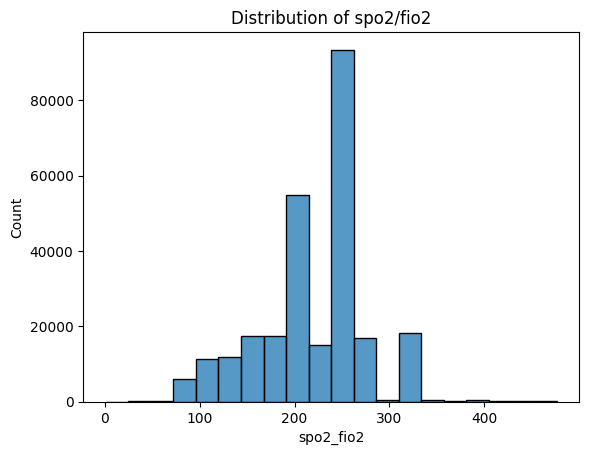

In [26]:
# spo2/fio2 check
import seaborn as sns

# 결측값 제외
sf_df = icu_events_df[icu_events_df['spo2_fio2']!=0]

print("spo2/fio2 빈도 수: ", len(sf_df))
print("spo2/fio2 Max: ", round(sf_df['spo2_fio2'].max(),2))
print("spo2/fio2 Min: ", sf_df['spo2_fio2'].min())
print("spo2/fio2 Median: ", sf_df['spo2_fio2'].median())

sns.histplot(sf_df['spo2_fio2'], bins=20)
plt.title('Distribution of spo2/fio2')
plt.show()

In [27]:
# 컬럼명 통일
icu_events_df = icu_events_df.rename(columns={
    'fluid_count': 'count_fluid_cumul',
    'bp_count': 'count_map',
    'urine_count': 'count_urine'
})

key_ids = final_static_df[['subject_id', 'hadm_id', 'stay_id']]
icu_events_df = icu_events_df.merge(key_ids, how='left', on='stay_id')

In [28]:
print(icu_events_df['subject_id'].nunique())
print(icu_events_df['hadm_id'].nunique())
print(icu_events_df['stay_id'].nunique())

10857
12987
14127


In [29]:
STD_VARS = [v for v in STD_VARS
            if v not in ['Brain Natiuretic Peptide', 'd-dimer', 'hematocrit']]
STD_VARS = STD_VARS + ['spo2_fio2']

EXTRA = {
    'fluid_cumul': 'count_fluid_cumul',
    'map':         'count_map',
    'urine':       'count_urine',
}

ALL_VARS   = STD_VARS + list(EXTRA.keys())
ALL_COUNTS = [f'count_{v}' for v in STD_VARS] + list(EXTRA.values())

missing = [c for c in ALL_VARS + ALL_COUNTS if c not in icu_events_df.columns]
assert not missing, f'icu_events_df에 없는 컬럼: {missing}'
print(f'[meta-sync] n_ts_vars={len(ALL_VARS)}  '
      f'(std={len(STD_VARS)}, extra={len(EXTRA)})')


LABEL_COL  = 'death_adm'
NUM_STATIC = ['age_at_intime']

# 모델 인풋에서 빼야 할 컬럼들 (식별자/시간/원본 카테고리/라벨)
DROP_COLS = [
    'subject_id', 'hadm_id', 'stay_id',
    'intime', 'outtime', 'admittime', 'dischtime',
    'first_careunit', 'last_careunit',
    'admission_location', 'admission_type', 'race', LABEL_COL
]

ONEHOT_STATIC = [c for c in final_static_df.columns if c not in DROP_COLS + NUM_STATIC]

D_STATIC = len(NUM_STATIC) + len(ONEHOT_STATIC)
print(f'd_static_num = {D_STATIC}  (numeric {len(NUM_STATIC)} + one-hot {len(ONEHOT_STATIC)})')
print('one-hot 컬럼들:', ONEHOT_STATIC)

ART_DIR = '/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/full_data/subject_data/mimic_3_1/'
os.makedirs(ART_DIR, exist_ok=True)

icu_events_df.reset_index(drop=True).to_feather(f'{ART_DIR}/icu_events_raw.ftr')
final_static_df.reset_index(drop=True).to_feather(f'{ART_DIR}/static_full.ftr')

with open(f'{ART_DIR}/meta.pkl', 'wb') as f:
    pickle.dump({
        'STD_VARS': STD_VARS,
        'EXTRA': EXTRA,
        'ALL_VARS': ALL_VARS,
        'ALL_COUNTS': ALL_COUNTS,
        'NUM_STATIC': NUM_STATIC,
        'ONEHOT_STATIC': ONEHOT_STATIC,
        'D_STATIC': D_STATIC,
        'LABEL_COL': LABEL_COL,
    }, f)

print('saved:', ART_DIR)
print(f'  icu_events_raw.ftr : {icu_events_df.shape}')
print(f'  static_full.ftr    : {final_static_df.shape}')
print(f'  meta.pkl           : D_STATIC={D_STATIC}, n_vars={len(ALL_VARS)}')

[meta-sync] n_ts_vars=34  (std=31, extra=3)
d_static_num = 23  (numeric 1 + one-hot 22)
one-hot 컬럼들: ['admission_type_grouped_ELECTIVE', 'admission_type_grouped_EMERGENCY', 'admission_type_grouped_OBSERVATION', 'admission_location_grouped_EMERGENCY', 'admission_location_grouped_OTHER_UNKNOWN', 'admission_location_grouped_PROCEDURE_PACU', 'admission_location_grouped_REFERRAL', 'admission_location_grouped_TRANSFER', 'first_careunit_grouped_CARDIAC', 'first_careunit_grouped_MICU', 'first_careunit_grouped_MICU_SICU', 'first_careunit_grouped_NEURO', 'first_careunit_grouped_SICU', 'first_careunit_grouped_TSICU', 'race_ASIAN', 'race_BLACK', 'race_HISPANIC/LATINO', 'race_OTHER', 'race_UNKNOWN', 'race_WHITE', 'gender_F', 'gender_M']
saved: /home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/full_data/subject_data/mimic_3_1/
  icu_events_raw.ftr : (1617945, 72)
  static_full.ftr    : (14127, 31)
  meta.pkl           : D_STATIC=23, n_vars=34


---

# 2. Labeling

In [30]:
# icu_events_df = pd.read_feather("/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/full_data/subject_data/mimic_3_1/icu_events_df.ftr")

In [31]:
icu_events_df.columns

Index(['stay_id', 'slot_idx', 'albumin', 'alt', 'anion_gap', 'art_ph', 'ast',
       'base_excess', 'bilirubin', 'bun', 'ca_ion', 'chloride', 'ck_mb',
       'creatinine', 'fio2', 'gcs', 'glucose', 'heart_rate', 'hemoglobin',
       'lactate', 'o2sat', 'paco2', 'pao2', 'platelets', 'potassium', 'pt_inr',
       'ptt', 'resp_rate', 'sodium', 'temperature', 'troponin-T', 'wbc',
       'fluid_cumul', 'map', 'urine', 'count_albumin', 'count_alt',
       'count_anion_gap', 'count_art_ph', 'count_ast', 'count_base_excess',
       'count_bilirubin', 'count_bun', 'count_ca_ion', 'count_chloride',
       'count_ck_mb', 'count_creatinine', 'count_fio2', 'count_gcs',
       'count_glucose', 'count_heart_rate', 'count_hemoglobin',
       'count_lactate', 'count_o2sat', 'count_paco2', 'count_pao2',
       'count_platelets', 'count_potassium', 'count_pt_inr', 'count_ptt',
       'count_resp_rate', 'count_sodium', 'count_temperature',
       'count_troponin-T', 'count_wbc', 'count_fluid_cumul', 'coun

In [32]:
icu_events_df

,stay_id,slot_idx,albumin,alt,anion_gap,art_ph,ast,base_excess,bilirubin,bun,ca_ion,chloride,ck_mb,creatinine,fio2,gcs,glucose,heart_rate,hemoglobin,lactate,o2sat,paco2,pao2,platelets,potassium,pt_inr,ptt,resp_rate,sodium,temperature,troponin-T,wbc,fluid_cumul,map,urine,count_albumin,count_alt,count_anion_gap,count_art_ph,count_ast,count_base_excess,count_bilirubin,count_bun,count_ca_ion,count_chloride,count_ck_mb,count_creatinine,count_fio2,count_gcs,count_glucose,count_heart_rate,count_hemoglobin,count_lactate,count_o2sat,count_paco2,count_pao2,count_platelets,count_potassium,count_pt_inr,count_ptt,count_resp_rate,count_sodium,count_temperature,count_troponin-T,count_wbc,count_fluid_cumul,count_map,count_urine,spo2_fio2,count_spo2_fio2,subject_id,hadm_id
0,30000646,0,0.0,0.0,12.0,0.0,0.0,0.0,0.0,12.0,0.0,105.0,0.0,0.9,0.0,15.0,102.0,102.0,12.9,0.0,98.0,0.0,0.0,268.0,3.5,1.3,37.4,33.0,138.0,0.000000,0.00,8.5,320.614289,75.0,133.488717,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,2.0,1.0,0.0,2.0,0.0,0.0,1.0,1.0,1.0,1.0,2.0,1.0,0.0,0.0,1.0,2,2,0,0.0,0,12207593,22795209.0
1,30000646,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,97.0,0.0,0.0,94.0,0.0,0.0,0.0,0.0,0.0,0.0,19.0,0.0,0.000000,0.00,0.0,5.000507,67.0,133.488717,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0,1,0,0.0,0,12207593,22795209.0
2,30000646,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,93.0,0.0,0.0,98.0,0.0,0.0,0.0,0.0,0.0,0.0,18.0,0.0,0.000000,0.00,0.0,5.000507,67.0,133.488717,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0,1,0,0.0,0,12207593,22795209.0
3,30000646,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,87.0,0.0,0.0,98.0,0.0,0.0,0.0,0.0,0.0,0.0,24.0,0.0,37.111111,0.00,0.0,5.000507,73.0,133.488717,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0,1,0,0.0,0,12207593,22795209.0
4,30000646,4,0.0,22.0,12.0,0.0,19.0,0.0,0.7,12.0,0.0,107.0,1.0,1.0,100.0,0.0,108.0,94.0,13.2,0.0,100.0,0.0,0.0,337.0,3.7,1.3,35.3,30.0,141.0,39.111111,0.02,10.6,3365.000507,60.0,32.556415,0.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,11.0,1.0,0.0,11.0,0.0,0.0,1.0,1.0,1.0,1.0,11.0,1.0,1.0,1.0,1.0,4,7,1,100.0,1,12207593,22795209.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1617940,39998622,211,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,113.0,0.0,0.0,95.0,0.0,0.0,0.0,0.0,0.0,0.0,38.0,0.0,36.888889,0.00,0.0,105.000000,80.0,40.473164,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1,1,1,0.0,0,19046950,24352151.0
1617941,39998622,212,0.0,0.0,12.0,0.0,0.0,0.0,0.0,38.0,0.0,100.0,0.0,1.0,0.0,0.0,225.0,111.0,0.0,0.0,94.0,0.0,0.0,0.0,3.9,0.0,0.0,23.0,139.0,0.000000,0.00,0.0,5.000000,83.0,46.864407,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0,1,1,0.0,0,19046950,24352151.0
1617942,39998622,213,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0,0.0,108.0,0.0,0.0,93.0,0.0,0.0,0.0,0.0,0.0,0.0,35.0,0.0,36.944444,0.00,0.0,5.000000,93.0,324.258475,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0,1,1,0.0,0,19046950,24352151.0
1617943,39998622,214,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,106.0,0.0,0.0,93.0,0.0,0.0,0.0,0.0,0.0,0.0,35.0,0.0,0.000000,0.00,0.0,5.000000,82.0,175.741525,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0,1,1,0.0,0,

In [33]:
final_multimodal_df = pd.read_feather('/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/full_data/subject_data/cached_final_cxr_df_in_icu_20260713.ftr')
final_multimodal_df

,subject_id,hadm_id,stay_id,study_id,dicom_id,intime,outtime,slot_idx,cxr_flag,lung_mask_path,label_cardiomegaly,mask_cardiomegaly,loc_cardiomegaly,label_pneumonia,mask_pneumonia,loc_pneumonia,label_atelectasis,mask_atelectasis,loc_atelectasis,label_opacity,mask_opacity,loc_opacity,label_consolidation,mask_consolidation,loc_consolidation,label_edema,mask_edema,loc_edema,label_effusion,mask_effusion,raddino_emb_path,hybrid_emb_path,txt_path
0,10001884,26184834,37510196,57156853,9fd47edd-07087209-b901811e-3e9e5f50-f382f611,2131-01-11 04:20:05,2131-01-20 08:27:30,0,1,/home/DAHS1/gangmin/my_research/clinical_multi...,0.0,None,None,0.0,None,None,0.0,None,None,0.0,None,None,0.0,None,None,0.0,None,None,0.0,None,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...,/home/DAHS1/gangmin/my_research/clinical_multi...
1,10001884,26184834,37510196,None,None,2131-01-11 04:20:05,2131-01-20 08:27:30,1,0,None,NaN,None,None,NaN,None,None,NaN,None,None,NaN,None,None,NaN,None,None,NaN,None,None,NaN,None,None,None,None
2,10001884,26184834,37510196,None,None,2131-01-11 04:20:05,2131-01-20 08:27:30,2,0,None,NaN,None,None,NaN,None,None,NaN,None,None,NaN,None,None,NaN,None,None,NaN,None,None,NaN,None,None,None,None
3,10001884,26184834,37510196,None,None,2131-01-11 04:20:05,2131-01-20 08:27:30,3,0,None,NaN,None,None,NaN,None,None,NaN,None,None,NaN,None,None,NaN,None,None,NaN,None,None,NaN,None,None,None,None
4,10001884,26184834,37510196,None,None,2131-01-11 04:20:05,2131-01-20 08:27:30,4,0,None,NaN,None,None,NaN,None,None,NaN,None,None,NaN,None,None,NaN,None,None,NaN,None,None,NaN,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1617940,19999987,23865745,36195440,None,None,2145-11-02 22:59:00,2145-11-04 21:29:30,42,0,None,NaN,None,None,NaN,None,None,NaN,None,None,NaN,None,None,NaN,None,None,NaN,None,None,NaN,None,None,None,None
1617941,19999987,23865745,36195440,None,None,2145-11-02 22:59:00,2145-11-04 21:29:30,43,0,None,NaN,None,None,NaN,None,None,NaN,None,None,NaN,None,None,NaN,None,None,NaN,None,None,NaN,None,None,None,None
1617942,19999987,23865745,36195440,None,None,2145-11-02 22:59:00,2145-11-04 21:29:30,44,0,None,NaN,None,None,NaN,None,None,NaN,None,None,NaN,None,None,NaN,None,None,NaN,None,None,NaN,None,None,None,None
1617943,19999987,23865745,36195440,None,None,2145-11-02 22:59:00,2145-11-04 21:29:30,45,0,None,NaN,None,None,NaN,None,None,NaN,None,None,NaN,None,None,NaN,None,None,NaN,None,None,NaN,None,None,None,None


In [37]:
icu_events_df.dtypes

stay_id              int64
slot_idx             int64
albumin            float64
alt                float64
anion_gap          float64
                    ...   
count_urine          int64
spo2_fio2          float64
count_spo2_fio2      int64
subject_id           int64
hadm_id            float64
Length: 72, dtype: object

In [36]:
final_multimodal_df.dtypes

subject_id           object
hadm_id               int64
stay_id               int64
study_id             object
dicom_id             object
intime               object
outtime              object
slot_idx              int64
cxr_flag              int64
Pneumonia           float64
Consolidation       float64
Cardiomegaly        float64
Edema               float64
report               object
txt_path             object
raddino_emb_path     object
hybrid_emb_path      object
dtype: object

In [34]:
icu_events_df['subject_id'] = icu_events_df['subject_id'].astype(int)
icu_events_df['hadm_id'] = icu_events_df['hadm_id'].astype(int)
icu_events_df['stay_id'] = icu_events_df['stay_id'].astype(int)

final_multimodal_df['subject_id'] = final_multimodal_df['subject_id'].astype(int)
final_multimodal_df['hadm_id'] = final_multimodal_df['hadm_id'].astype(int)
final_multimodal_df['stay_id'] = final_multimodal_df['stay_id'].astype(int)

In [35]:
final_multimodal_df.columns

Index(['subject_id', 'hadm_id', 'stay_id', 'study_id', 'dicom_id', 'intime',
       'outtime', 'slot_idx', 'cxr_flag', 'lung_mask_path',
       'label_cardiomegaly', 'mask_cardiomegaly', 'loc_cardiomegaly',
       'label_pneumonia', 'mask_pneumonia', 'loc_pneumonia',
       'label_atelectasis', 'mask_atelectasis', 'loc_atelectasis',
       'label_opacity', 'mask_opacity', 'loc_opacity', 'label_consolidation',
       'mask_consolidation', 'loc_consolidation', 'label_edema', 'mask_edema',
       'loc_edema', 'label_effusion', 'mask_effusion', 'raddino_emb_path',
       'hybrid_emb_path', 'txt_path'],
      dtype='object')

In [37]:
# 일단은 edema 라벨만 사용하며, text랑 segment는 제외하고 하자
final_df = final_multimodal_df.merge(icu_events_df, how='left', on=['subject_id', 'hadm_id', 'stay_id', 'slot_idx'])
final_df = final_df.drop(columns=[
    # 'label_cardiomegaly', 'loc_cardiomegaly',
    # 'label_pneumonia', 'loc_pneumonia',
    # 'label_atelectasis', 'loc_atelectasis',
    # 'label_opacity', 'loc_opacity', 
    # 'label_consolidation', 'loc_consolidation', 
    # 'label_edema', 'loc_edema', 
    # 'label_effusion', 'loc_effusion',

    'mask_cardiomegaly', 'mask_pneumonia', 'mask_atelectasis', 'mask_opacity', 'mask_consolidation', 'mask_edema', 'mask_effusion',
    'lung_mask_path', 'txt_path', 'hybrid_emb_path'
])

In [39]:
final_df.head()

,subject_id,hadm_id,stay_id,study_id,dicom_id,intime,outtime,slot_idx,cxr_flag,label_cardiomegaly,loc_cardiomegaly,label_pneumonia,loc_pneumonia,label_atelectasis,loc_atelectasis,label_opacity,loc_opacity,label_consolidation,loc_consolidation,label_edema,loc_edema,label_effusion,raddino_emb_path,albumin,alt,anion_gap,art_ph,ast,base_excess,bilirubin,bun,ca_ion,chloride,ck_mb,creatinine,fio2,gcs,glucose,heart_rate,hemoglobin,lactate,o2sat,paco2,pao2,platelets,potassium,pt_inr,ptt,resp_rate,sodium,temperature,troponin-T,wbc,fluid_cumul,map,urine,count_albumin,count_alt,count_anion_gap,count_art_ph,count_ast,count_base_excess,count_bilirubin,count_bun,count_ca_ion,count_chloride,count_ck_mb,count_creatinine,count_fio2,count_gcs,count_glucose,count_heart_rate,count_hemoglobin,count_lactate,count_o2sat,count_paco2,count_pao2,count_platelets,count_potassium,count_pt_inr,count_ptt,count_resp_rate,count_sodium,count_temperature,count_troponin-T,count_wbc,count_fluid_cumul,count_map,count_urine,spo2_fio2,count_spo2_fio2
0,10001884,26184834,37510196,57156853,9fd47edd-07087209-b901811e-3e9e5f50-f382f611,2131-01-11 04:20:05,2131-01-20 08:27:30,0,1,0.0,None,0.0,None,0.0,None,0.0,None,0.0,None,0.0,None,0.0,/home/DAHS1/gangmin/my_research/clinical_multi...,0.0,0.0,17.0,7.22,0.0,6.0,0.0,27.0,0.00,0.0,20.0,1.1,0.0,0.0,141.0,60.0,13.0,1.7,98.0,94.0,74.0,218.0,4.5,0.0,0.0,10.0,130.0,0.0,0.05,12.2,124.974784,70.0,58.946115,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,8,2,0,0.0,0
1,10001884,26184834,37510196,None,None,2131-01-11 04:20:05,2131-01-20 08:27:30,1,0,NaN,None,NaN,None,NaN,None,NaN,None,NaN,None,NaN,None,NaN,None,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,72.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,20.0,0.0,0.0,0.00,0.0,31.820122,75.0,58.946115,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0,1,0,0.0,0
2,10001884,26184834,37510196,None,None,2131-01-11 04:20:05,2131-01-20 08:27:30,2,0,NaN,None,NaN,None,NaN,None,NaN,None,NaN,None,NaN,None,NaN,None,3.5,167.0,11.0,7.33,134.0,6.0,0.4,30.0,1.25,90.0,14.0,1.1,50.0,0.0,140.0,70.0,12.1,1.5,100.0,69.0,49.0,171.0,3.9,1.4,0.0,20.0,134.0,35.4,0.08,18.4,46.976525,73.0,58.946115,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,1.0,1.0,1.0,0.0,2.0,3.0,2.0,1.0,3.0,1.0,1.0,1.0,2.0,1.0,0.0,3.0,2.0,2.0,1.0,1.0,6,2,0,200.0,1
3,10001884,26184834,37510196,None,None,2131-01-11 04:20:05,2131-01-20 08:27:30,3,0,NaN,None,NaN,None,NaN,None,NaN,None,NaN,None,NaN,None,NaN,None,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,3.0,0.0,71.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,20.0,0.0,35.8,0.00,0.0,254.893067,80.0,71.560173,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,11,1,1,0.0,0
4,10001884,26184834,37510196,None,None,2131-01-11 04:20:05,2131-01-20 08:27:30,4,0,NaN,None,NaN,None,NaN,None,NaN,None,NaN,None,NaN,None,NaN,None,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,71.0,0.0,0.0,98.0,0.0,0.0,0.0,0.0,0.0,0.0,20.0,0.0,36.3,0.00,0.0,37.298313,92.0,123.782818,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,5,1,1,0.0,0


In [40]:
final_df['label_edema'].value_counts()

label_edema
0.0    34837
1.0     7462
Name: count, dtype: int64

In [41]:
final_df.to_feather('/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/full_data/subject_data/mimic_3_1/final_df_20260713')
# 나중에 demo 정보도 붙여서 tabular 모달리티로 쓰자


In [42]:
final_df.columns

Index(['subject_id', 'hadm_id', 'stay_id', 'study_id', 'dicom_id', 'intime',
       'outtime', 'slot_idx', 'cxr_flag', 'label_cardiomegaly',
       'loc_cardiomegaly', 'label_pneumonia', 'loc_pneumonia',
       'label_atelectasis', 'loc_atelectasis', 'label_opacity', 'loc_opacity',
       'label_consolidation', 'loc_consolidation', 'label_edema', 'loc_edema',
       'label_effusion', 'raddino_emb_path', 'albumin', 'alt', 'anion_gap',
       'art_ph', 'ast', 'base_excess', 'bilirubin', 'bun', 'ca_ion',
       'chloride', 'ck_mb', 'creatinine', 'fio2', 'gcs', 'glucose',
       'heart_rate', 'hemoglobin', 'lactate', 'o2sat', 'paco2', 'pao2',
       'platelets', 'potassium', 'pt_inr', 'ptt', 'resp_rate', 'sodium',
       'temperature', 'troponin-T', 'wbc', 'fluid_cumul', 'map', 'urine',
       'count_albumin', 'count_alt', 'count_anion_gap', 'count_art_ph',
       'count_ast', 'count_base_excess', 'count_bilirubin', 'count_bun',
       'count_ca_ion', 'count_chloride', 'count_ck_mb', 'coun